In [ ]:
import requests
from PIL import Image
import torch

from transformers import OwlViTProcessor, OwlViTForObjectDetection

import matplotlib.pyplot as plt
import matplotlib.patches as patches

processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
text_labels = [["a photo of a cat", "a photo of a dog"]]
inputs = processor(text=text_labels, images=image, return_tensors="pt")
outputs = model(**inputs)

target_sizes = torch.tensor([(image.height, image.width)])

results = processor.post_process_grounded_object_detection(
    outputs=outputs, target_sizes=target_sizes, threshold=0.1, text_labels=text_labels
)

result = results[0]
boxes, scores, text_labels = result["boxes"], result["scores"], result["text_labels"]
for box, score, text_label in zip(boxes, scores, text_labels):
    box = [round(i, 2) for i in box.tolist()]
    print(f"Detected {text_label} with confidence {round(score.item(), 3)} at location {box}")

Detected a photo of a cat with confidence 0.707 at location [324.97, 20.44, 640.58, 373.29]
Detected a photo of a cat with confidence 0.717 at location [1.46, 55.26, 315.55, 472.17]


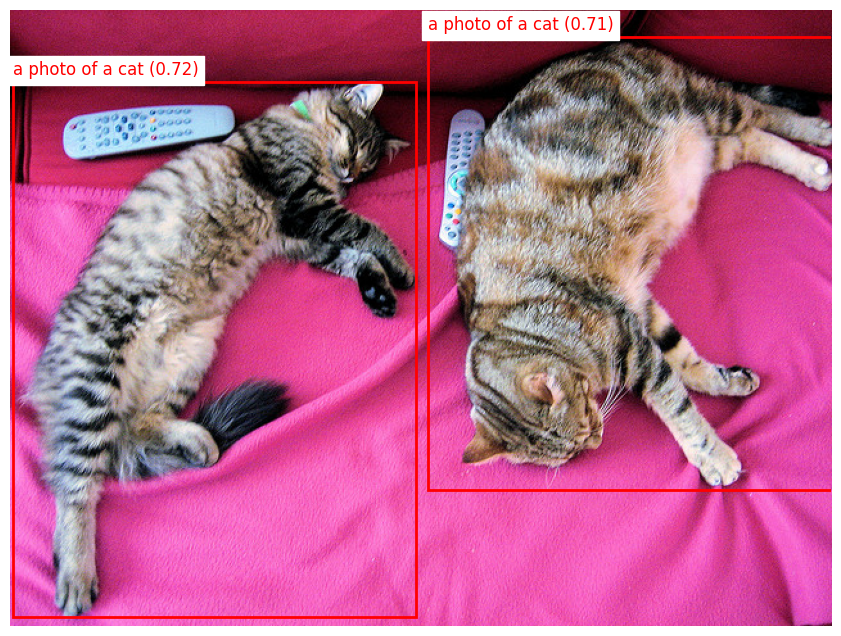

In [3]:
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

# Draw each bounding box
for box, score, text_label in zip(boxes, scores, text_labels):
    # Convert tensor to list safely
    box = box.detach().cpu().numpy()
    xmin, ymin, xmax, ymax = box

    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(
        xmin,
        ymin - 5,
        f"{text_label} ({score:.2f})",
        color="red",
        fontsize=12,
        backgroundcolor="white",
    )

plt.axis("off")
plt.show()